# Data Exploration

In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

## a)

In [2]:
df = pd.read_csv("insurance_orig.csv")
df.shape

(1349, 7)

7 Columns and 1349 rows

## b)

In [3]:
df.describe()

,age,bmi,children,charges
count,1348.000000,1347.000000,1348.000000,1347.000000
mean,39.228487,30.655499,1.103858,13254.716622
std,14.063585,6.085427,1.217132,12096.109347
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.315000,0.000000,4742.306100
50%,39.000000,30.360000,1.000000,9377.904700
75%,51.000000,34.637500,2.000000,16582.138605
max,64.000000,53.130000,7.000000,63770.428010


## c)

In [4]:
df_without_nan= df.dropna()
display(df_without_nan)
display(df_without_nan.shape)

,age,sex,bmi,children,smoker,region,charges
0,23.0,male,23.845,0.0,no,northeast,2395.17155
1,60.0,female,36.005,0.0,no,northeast,13228.84695
2,34.0,female,31.920,1.0,yes,northeast,37701.87680
3,19.0,female,28.600,5.0,no,southwest,4687.79700
4,19.0,male,20.425,0.0,no,northwest,1625.43375
...,...,...,...,...,...,...,...
1344,50.0,male,30.970,3.0,no,northwest,10600.54830
1345,18.0,female,31.920,0.0,no,northeast,2205.98080
1346,18.0,female,36.850,0.0,no,southeast,1629.83350
1347,21.0,female,25.800,0.0,no,southwest,2007.94500


(1338, 7)

1338 rows

## d)

In [5]:
import numpy as np
conditions = [
    df_without_nan['bmi'] < 18.5,
    (df_without_nan['bmi'] >= 18.5) & (df_without_nan['bmi'] < 25),
    (df_without_nan['bmi'] >= 25) & (df_without_nan['bmi'] < 30),
    df_without_nan['bmi'] >= 30
]

bmi_class = ['underweight', 'normal weight', 'overweight', 'obese']

df_with_bmi_class = df_without_nan.copy()
df_with_bmi_class['bmi_class'] = np.select(conditions, bmi_class)
num_underweight = df_with_bmi_class.loc[df_with_bmi_class['bmi_class'] == 'underweight']['bmi_class'].count()
num_normal = df_with_bmi_class.loc[df_with_bmi_class['bmi_class'] == 'normal weight']['bmi_class'].count()
num_overweight = df_with_bmi_class.loc[df_with_bmi_class['bmi_class'] == 'overweight']['bmi_class'].count()
num_obese = df_with_bmi_class.loc[df_with_bmi_class['bmi_class'] == 'obese']['bmi_class'].count()

print(f'Number of underweight : {num_underweight}.')
print(f'Number of normal weight : {num_normal}.')
print(f'Number of overweight : {num_overweight}.')
print(f'Number of obese : {num_obese}.')


Number of underweight : 20.
Number of normal weight : 225.
Number of overweight : 386.
Number of obese : 707.


## e)

Text(0, 0.5, 'Number of data')

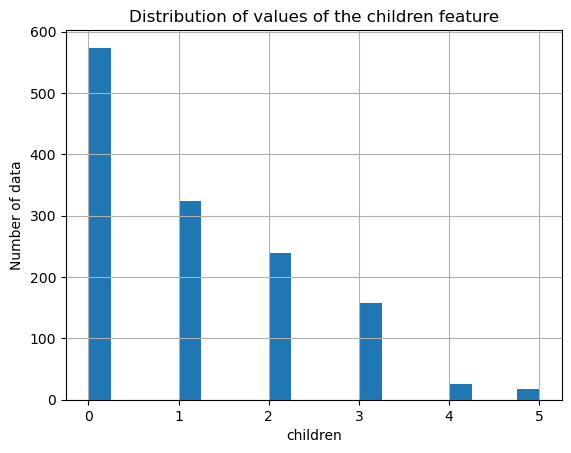

In [6]:

df_without_nan['children'].hist(bins=20)
plt.pyplot.title("Distribution of values of the children feature")
plt.pyplot.xlabel("children")
plt.pyplot.ylabel("Number of data")

The mode of the children feature is 0.

## f)

<Axes: title={'center': 'Distribution of values of the charges feature with 25 bins'}, xlabel='charges', ylabel='Number of data'>

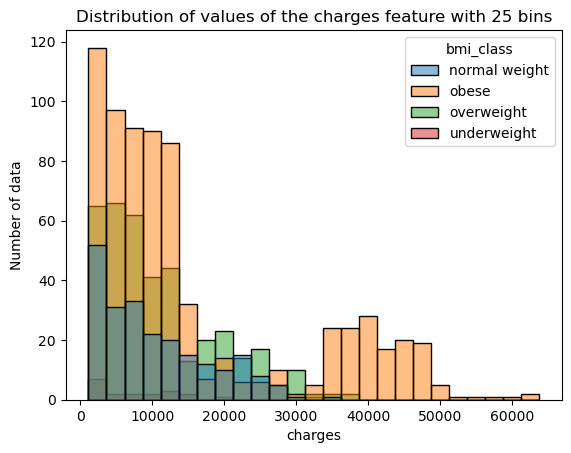

In [7]:

plt.pyplot.title("Distribution of values of the charges feature with 25 bins")
plt.pyplot.xlabel("charges")
plt.pyplot.ylabel("Number of data")
sns.histplot(data=df_with_bmi_class, x='charges', hue='bmi_class',bins = 25)


## g)

At lower charges, between 0 and 30,000, the BMI classes are well distributed. However, above 30,000, the obese BMI class completely dominates the distribution, and the other classes are barely visible. This indicates a trend: the higher the charges, the more likely it is that the patient has a high BMI.

## h)

Text(0.5, 1.02, 'Scatter plot matrix for the columns age, bmi, children, and charges')

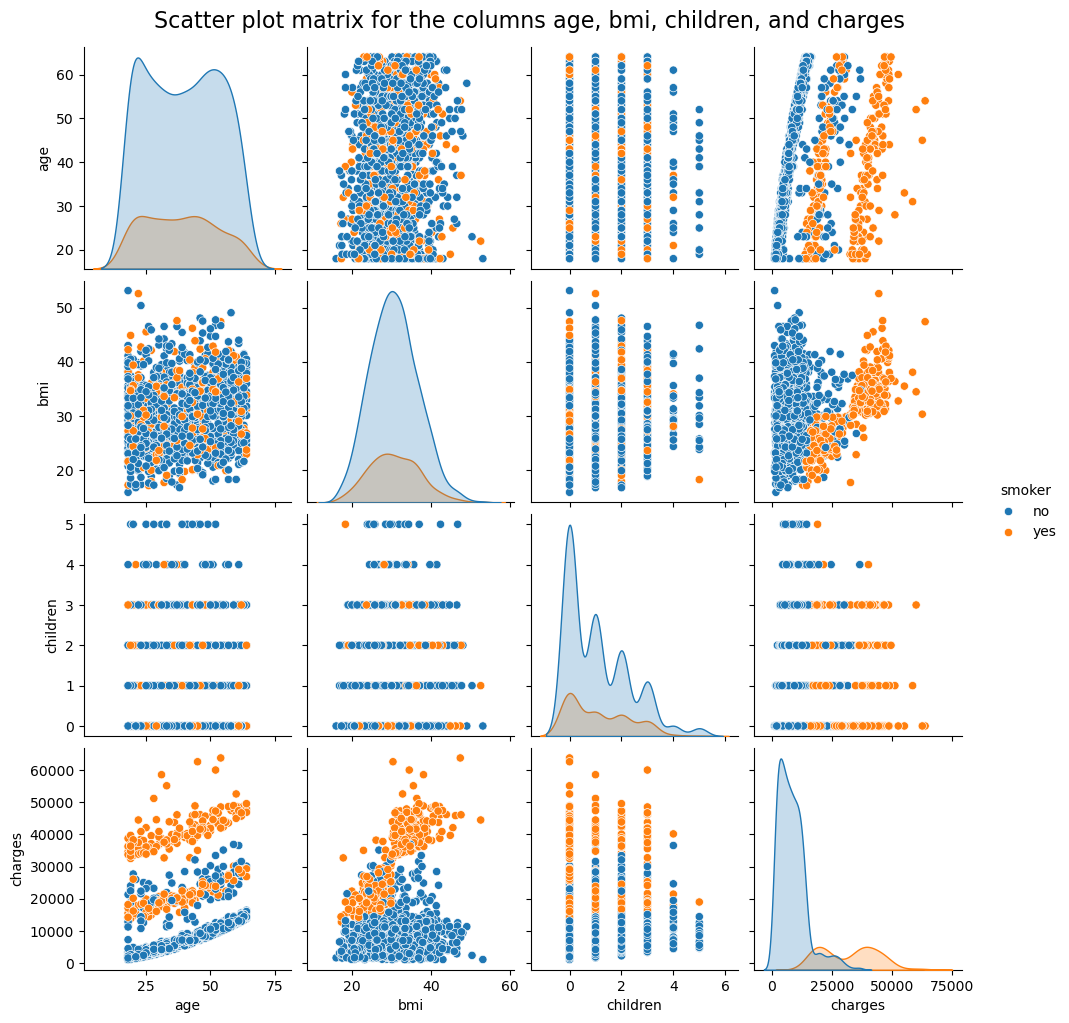

In [8]:
sns.pairplot(df_with_bmi_class, hue='smoker') 
plt.pyplot.suptitle('Scatter plot matrix for the columns age, bmi, children, and charges', y=1.02, fontsize=16)

## i)

In [9]:
correlation_columns=['age','bmi','children','charges']
df_with_bmi_class[correlation_columns].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


## j)

1. There are more smokers with charges above 20,000. <br>
2. No, there is no value below the lower fence value. <br>
3. The question cannot be answered. The boxplot of the charges grouped by smokers and non-smokers among the individuals does not provide the mean. <br>
4. Yes, the lower 1st quartile fence of smokers lower than the upper whisker of the 
non-smokers
